In [1]:
import pandas as pd

#======================================
# Dataset load
#======================================

df = pd.read_csv("online_retail.csv")

#======================================
# basic dataset info
#======================================

# print('\n=========== data shape ===========\n')
# print(df.shape)

# print('\n=========== columns ===========\n')
# print(df.columns)

# print('\n=========== 1st 5 rows ===========\n')
# print(df.head())

# print('\n=========== last 5 rows ===========\n')
# print(df.tail())

# print('\n=========== random sample ===========\n')
# print(df.sample(5))

#======================================
# basic dataset info
#======================================

print('\n=========== info ===========\n')
print(df.info())

#======================================
# numerical summary
#======================================

print('\n=========== describe ===========\n')
print(df.describe())


=========== info ===========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

=========== describe ===========

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000

In [ ]:
#======================================
# missing values
#======================================

print('\n=========== missing values ===========\n')
print(df.isnull().sum())

#======================================
# duplicate rows
#======================================

print('\n=========== duplicate rows ===========\n')
print(df.duplicated().sum())

#======================================
# unique values
#======================================

print('\n=========== unique values ===========\n')
print("invoices    :",df["InvoiceNo"].nunique())
print("StockCode   :",df["StockCode"].nunique())
print("Description :",df["Description"].nunique())
print("CustomerID  :",df["CustomerID"].nunique())
print("Country     :",df["Country"].nunique())


=========== missing values ===========

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=========== duplicate rows ===========

5268

=========== unique values ===========

invoices    : 25900
StockCode   : 4070
Description : 4223
CustomerID  : 4372
Country     : 38


In [ ]:
#======================================
# suspecious values
#======================================

print('\n=========== suspecious values ===========\n')
print('Negative quantity :', (df['Quantity']<0).sum())
print('zero quantity     :', (df['Quantity']==0).sum())
print('Negative price    :', (df['UnitPrice']<0).sum())
print('zero price        :', (df['UnitPrice']==0).sum())




=========== suspecious values ===========

Negative quantity : 10624
zero quantity     : 0
Negative price    : 2
zero price        : 2515


# Investigate Data Quality Issues

In [ ]:
print('\n=========== missing descritption ===========\n')
print(df[df['Description'].isnull()].head())

print("\n========== MISSING CUSTOMER IDs ==========\n")
print(df[df["CustomerID"].isnull()].head())

print("\n========== DUPLICATE ROWS ==========\n")
print(df[df.duplicated()].head())

print("\n========== NEGATIVE QUANTITY ==========\n")
print(df[df["Quantity"] < 0].head())

print("\n========== NEGATIVE PRICE ==========\n")
print(df[df["UnitPrice"] < 0])

print("\n========== ZERO PRICE ==========\n")
print(df[df["UnitPrice"] == 0].head())


=========== missing descritption ===========

     InvoiceNo StockCode Description  Quantity          InvoiceDate  \
622     536414     22139         NaN        56  2010-12-01 11:52:00   
1970    536545     21134         NaN         1  2010-12-01 14:32:00   
1971    536546     22145         NaN         1  2010-12-01 14:33:00   
1972    536547     37509         NaN         1  2010-12-01 14:33:00   
1987    536549    85226A         NaN         1  2010-12-01 14:34:00   

      UnitPrice  CustomerID         Country  
622         0.0         NaN  United Kingdom  
1970        0.0         NaN  United Kingdom  
1971        0.0         NaN  United Kingdom  
1972        0.0         NaN  United Kingdom  
1987        0.0         NaN  United Kingdom  

========== MISSING CUSTOMER IDs ==========

     InvoiceNo StockCode                      Description  Quantity  \
622     536414     22139                              NaN        56   
1443    536544     21773  DECORATIVE ROSE BATHROOM BOTTLE      

#Pattern Investigation

In [ ]:
print("\n========== CANCELLATION INVOICES ==========\n")

print('invoices startting with c :', df['InvoiceNo'].astype(str).str.startswith('C').sum())

print('\n negative quantity rows :', (df['Quantity']<0).sum())

print("\n========== MISSING DESCRIPTION & ZERO PRICE ==========\n")
print(df[df['Description'].isnull() & (df['UnitPrice']==0)].shape)

print("\n========== MISSING DESCRIPTION & missing customer ==========\n")
print(df[df['Description'].isnull() & df['CustomerID'].isnull()].shape)

print("\n========== zero price & missing customer ==========\n")
print(df[(df['UnitPrice']==0) & df['CustomerID'].isnull()].shape)


========== CANCELLATION INVOICES ==========

invoices startting with c : 9288

 negative quantity rows : 10624

========== MISSING DESCRIPTION & ZERO PRICE ==========

(1454, 8)

========== MISSING DESCRIPTION & missing customer ==========

(1454, 8)

========== zero price & missing customer ==========

(2475, 8)


#Investigation of cancelled

In [ ]:
cancelled  =df[df['InvoiceNo'].str.startswith('C')]
print(cancelled.head())
print('\nrows              :',len(cancelled))
print('\nnegative quantity :',(cancelled['Quantity']<0).sum())
print('\nzero price :',(cancelled['UnitPrice']==0).sum())
print('\nnegative price :',(cancelled['UnitPrice']<0).sum())

print('\n====================mysterious data====================\n')
mystery = df[(df['UnitPrice']==0) &
             df['CustomerID'].isnull() & df['Description'].notnull()]

print(mystery.head(15))

    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

             InvoiceDate  UnitPrice  CustomerID         Country  
141  2010-12-01 09:41:00      27.50     14527.0  United Kingdom  
154  2010-12-01 09:49:00       4.65     15311.0  United Kingdom  
235  2010-12-01 10:24:00       1.65     17548.0  United Kingdom  
236  2010-12-01 10:24:00       0.29     17548.0  United Kingdom  
237  2010-12-01 10:24:00       0.29     17548.0  United Kingdom  

rows              : 9288

negative quantity : 9288

zero price : 0

negative price : 0

====================mysterious data====================

      InvoiceNo StockCode      

#Duplicate investigation

In [ ]:
duplicates = df[df.duplicated(keep=False)]

print(duplicates.sort_values(by=['InvoiceNo','StockCode']).head(15))

    InvoiceNo StockCode                          Description  Quantity  \
494    536409     21866          UNION JACK FLAG LUGGAGE TAG         1   
517    536409     21866          UNION JACK FLAG LUGGAGE TAG         1   
485    536409     22111         SCOTTIE DOG HOT WATER BOTTLE         1   
539    536409     22111         SCOTTIE DOG HOT WATER BOTTLE         1   
489    536409     22866        HAND WARMER SCOTTY DOG DESIGN         1   
527    536409     22866        HAND WARMER SCOTTY DOG DESIGN         1   
521    536409     22900      SET 2 TEA TOWELS I LOVE LONDON          1   
537    536409     22900      SET 2 TEA TOWELS I LOVE LONDON          1   
565    536412     21448            12 DAISY PEGS IN WOOD BOX         2   
578    536412     21448            12 DAISY PEGS IN WOOD BOX         1   
598    536412     21448            12 DAISY PEGS IN WOOD BOX         1   
601    536412     21448            12 DAISY PEGS IN WOOD BOX         2   
604    536412     21448            12 

#Cleaning

In [2]:
# =====================================================
# Create Working Copy
# =====================================================

df_clean = df.copy()

# =====================================================
# remove duplicates
# =====================================================
duplicates_removed = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

print('\n===================== Duplicate Rows=====================\n')
print("Duplicates Removed :", duplicates_removed)
print("\nCurrent Shape :", df_clean.shape)

# =====================================================
# remove cancelled orders
# =====================================================

cancelled_orders = df_clean['InvoiceNo'].astype(str).str.startswith('C')

df_clean = df_clean[~cancelled_orders]
print('\n=====================cancelled orders=====================\n')
print('cancelled rows count: ', cancelled_orders.sum())
print('current shape :', df_clean.shape)




===================== Duplicate Rows=====================

Duplicates Removed : 5268

Current Shape : (536641, 8)

=====================cancelled orders=====================

cancelled rows count:  9251
current shape : (527390, 8)


In [3]:
# =====================================================
# Remove Negative Price Rows
# =====================================================

negative_price = df_clean["UnitPrice"] < 0
negative_price_removed = negative_price.sum()
df_clean = df_clean[~negative_price]

print("\n========== NEGATIVE PRICE ROWS ==========\n")
print("Rows Removed :", negative_price_removed)

print("\nCurrent Shape :", df_clean.shape)

# =====================================================
# Remove Missing Descriptions
# =====================================================

missing_description = df_clean["Description"].isnull()
missing_description_removed = missing_description.sum()
df_clean = df_clean[~missing_description]

print("\n========== Missing Descriptions ==========\n")
print("Rows Removed :", missing_description_removed)
print("\nCurrent Shape :", df_clean.shape)

# =====================================================
# Remove Zero Price Rows
# =====================================================

zero_price = df_clean["UnitPrice"] == 0
zero_price_removed = zero_price.sum()
df_clean = df_clean[~zero_price]

print("\n========== ZERO PRICE ROWS ==========\n")
print("Rows Removed :", zero_price_removed)

print("\nCurrent Shape :", df_clean.shape)


========== NEGATIVE PRICE ROWS ==========

Rows Removed : 2

Current Shape : (527388, 8)

========== Missing Descriptions ==========

Rows Removed : 1454

Current Shape : (525934, 8)

========== ZERO PRICE ROWS ==========

Rows Removed : 1056

Current Shape : (524878, 8)


# Data type conversion

In [4]:
# =====================================================
# Convert InvoiceDate
# =====================================================

df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

print("\n========== INVOICE DATE ==========\n")
print(df_clean["InvoiceDate"].dtype)

# =====================================================
# Convert CustomerID
# =====================================================

df_clean["CustomerID"] = (df_clean["CustomerID"].astype("Int64"))

print("\n========== CUSTOMER ID ==========\n")
print(df_clean["CustomerID"].dtype)

# =====================================================
# Reset Index
# =====================================================

df_clean = df_clean.reset_index(drop=True)

print("\n========== FINAL SHAPE ==========\n")
print(df_clean.shape)




========== INVOICE DATE ==========

datetime64[ns]

========== CUSTOMER ID ==========

Int64

========== FINAL SHAPE ==========

(524878, 8)


#Feature Engineering

In [5]:
df_clean["Revenue"] = df_clean["Quantity"] *df_clean["UnitPrice"]

print("\n========== REVENUE COLUMN ==========\n")
print(df_clean[["Quantity", "UnitPrice", "Revenue"]].head())

# =====================================================
# Date Features
# =====================================================

df_clean["Year"] = (df_clean["InvoiceDate"].dt.year)

df_clean["Month"] = (df_clean["InvoiceDate"].dt.month)

df_clean["MonthName"] = (df_clean["InvoiceDate"].dt.month_name())

print("\n========== DATE FEATURES ==========\n")

print(df_clean[["InvoiceDate", "Year", "Month", "MonthName"]].head())




========== REVENUE COLUMN ==========

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34

========== DATE FEATURES ==========

          InvoiceDate  Year  Month MonthName
0 2010-12-01 08:26:00  2010     12  December
1 2010-12-01 08:26:00  2010     12  December
2 2010-12-01 08:26:00  2010     12  December
3 2010-12-01 08:26:00  2010     12  December
4 2010-12-01 08:26:00  2010     12  December


#Business KPIs

In [6]:
total_revenue = df_clean["Revenue"].sum()

total_orders = df_clean["InvoiceNo"].nunique()

total_products_sold = df_clean["Quantity"].sum()

unique_customers = df_clean["CustomerID"].nunique()

average_order_value = (total_revenue /total_orders)

print("\n========== BUSINESS KPIs ==========\n")

print(f"Total Revenue         : ${total_revenue:,.2f}")

print(f"Total Orders          : {total_orders:,}")

print(f"Products Sold         : {total_products_sold:,}")

print(f"Unique Customers      : {unique_customers:,}")

print(f"Average Order Value   : ${average_order_value:,.2f}")


========== BUSINESS KPIs ==========

Total Revenue         : $10,642,110.80
Total Orders          : 19,960
Products Sold         : 5,572,420
Unique Customers      : 4,338
Average Order Value   : $533.17


#product analysis

In [7]:
product_revenue =( df_clean.groupby('Description')
                  .agg(totalRevenue=('Revenue','sum'),
                       totalQuantity=('Quantity','sum'),
                       totalOrders=('InvoiceNo','nunique'))
                  .sort_values(by='totalRevenue',ascending=False)
)

print("\n========== TOP 10 PRODUCTS BY REVENUE ==========\n")
print(product_revenue.head(10))

# =====================================================
# Best Selling Products
# =====================================================

best_selling_products = product_revenue.sort_values(by='totalQuantity',ascending=False)

print("\n========== TOP 10 BEST SELLING PRODUCTS ==========\n")
print(best_selling_products.head(10))


========== TOP 10 PRODUCTS BY REVENUE ==========

                                    totalRevenue  totalQuantity  totalOrders
Description                                                                 
DOTCOM POSTAGE                         206248.77            706          706
REGENCY CAKESTAND 3 TIER               174156.54          13851         1988
PAPER CRAFT , LITTLE BIRDIE            168469.60          80995            1
WHITE HANGING HEART T-LIGHT HOLDER     106236.72          37872         2256
PARTY BUNTING                           99445.23          18283         1685
JUMBO BAG RED RETROSPOT                 94159.81          48371         2089
MEDIUM CERAMIC TOP STORAGE JAR          81700.92          78033          247
POSTAGE                                 78101.88           3150         1126
Manual                                  77752.82           6985          290
RABBIT NIGHT LIGHT                      66870.03          30739          994

========== TOP 10 BEST S

#country analysis

In [10]:
country_summary = (df_clean.groupby('Country')
                    .agg(totalRevenue=('Revenue','sum'),
                         totalorders=('InvoiceNo','nunique'),
                         totalCustomers=('CustomerID','nunique'),
                         productsSold=('Quantity','sum')))
top_countries = (country_summary.sort_values(by='totalRevenue',ascending=False))

print("\n========== TOP 10 COUNTRIES ==========\n")
print(top_countries.head(10))


========== TOP 10 COUNTRIES ==========

                totalRevenue  totalorders  totalCustomers  productsSold
Country                                                                
United Kingdom   9001744.094        18019            3920       4646906
Netherlands       285446.340           94               9        200361
EIRE              283140.520          288               3        147007
Germany           228678.400          457              94        119154
France            209625.370          392              87        112060
Australia         138453.810           57               9         83891
Spain              61558.560           90              30         27933
Switzerland        57067.600           54              21         30617
Belgium            41196.340           98              25         23237
Sweden             38367.830           36               8         36078


#monthly summary

In [11]:
monthly_summary  = (df_clean.groupby(['Year','Month','MonthName'])
                  .agg(TotalRevenue=("Revenue", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        ProductsSold=("Quantity", "sum"),
        UniqueCustomers=("CustomerID", "nunique"))
                  .reset_index())

monthly_summary = (monthly_summary.sort_values(by=["Year", "Month"]))

print("\n========== MONTHLY SALES ==========\n")
print(monthly_summary)


========== MONTHLY SALES ==========

    Year  Month  MonthName  TotalRevenue  TotalOrders  ProductsSold  \
0   2010     12   December    821452.730         1559        358019   
1   2011      1    January    689811.610         1086        387099   
2   2011      2   February    522545.560         1100        282934   
3   2011      3      March    716215.260         1454        376599   
4   2011      4      April    536968.491         1246        307953   
5   2011      5        May    769296.610         1681        395001   
6   2011      6       June    760547.010         1533        388511   
7   2011      7       July    718076.121         1475        399693   
8   2011      8     August    757841.380         1361        421020   
9   2011      9  September   1056435.192         1837        569573   
10  2011     10    October   1151263.730         2040        621029   
11  2011     11   November   1503866.780         2769        751377   
12  2011     12   December    637790.33

#customer summary

In [12]:
customer_summary = (
    df_clean.groupby("CustomerID")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        ProductsPurchased=("Quantity", "sum")
    )
)

customer_summary = (customer_summary.sort_values(by="TotalRevenue",ascending=False))

print("\n========== TOP 10 CUSTOMERS ==========\n")
print(customer_summary.head(10))



========== TOP 10 CUSTOMERS ==========

            TotalRevenue  TotalOrders  ProductsPurchased
CustomerID                                              
14646          280206.02           73             196915
18102          259657.30           60              64124
17450          194390.79           46              69973
16446          168472.50            2              80997
14911          143711.17          201              80240
12415          124914.53           21              77374
14156          117210.08           55              57768
17511           91062.38           31              64549
16029           80850.84           63              40108
12346           77183.60            1              74215


#files importing

In [33]:
import os

os.makedirs('reports',exist_ok=True)
os.makedirs("cleaned", exist_ok=True)

# =====================================================
# Export Reports
# =====================================================

customer_summary.to_csv('reports/customer_summary.csv')
product_revenue.to_csv('reports/product_summary.csv')
country_summary.to_csv('reports/country_summary.csv')
monthly_summary.to_csv('reports/monthly_summary.csv')
df_clean.to_csv("cleaned/online_retail_clean.csv",index=False)

#Monthly Revenue Trend

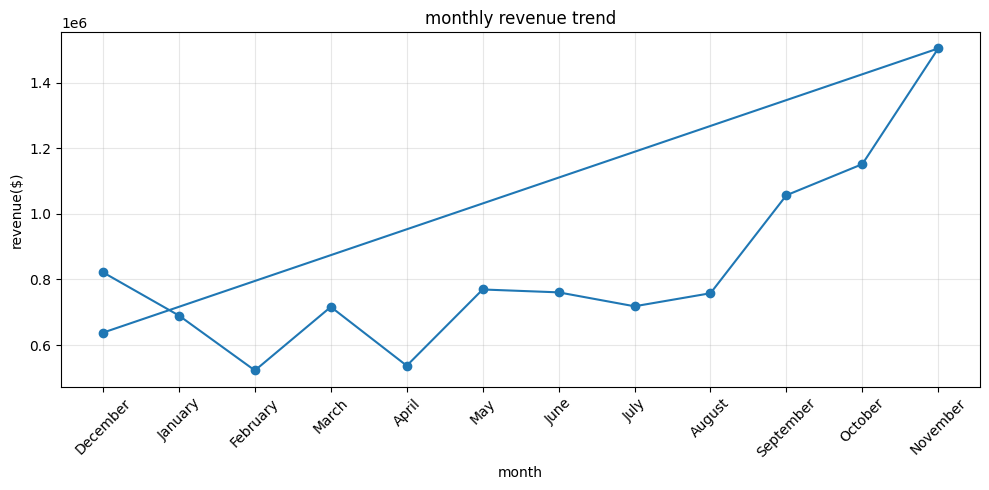

In [15]:
import os
import matplotlib.pyplot as plt

os.makedirs('images',exist_ok=True)

plt.figure(figsize=(10,5))
plt.plot(monthly_summary['MonthName'], monthly_summary['TotalRevenue'], marker='o')

plt.title("monthly revenue trend")
plt.xlabel('month')
plt.ylabel('revenue($)')
plt.xticks(rotation=45)
plt.grid(alpha=.3)
plt.tight_layout()

plt.savefig('images/monthly_revenue_trend.png', dpi=300, bbox_inches='tight')

plt.show()

#top 10 products by revenue

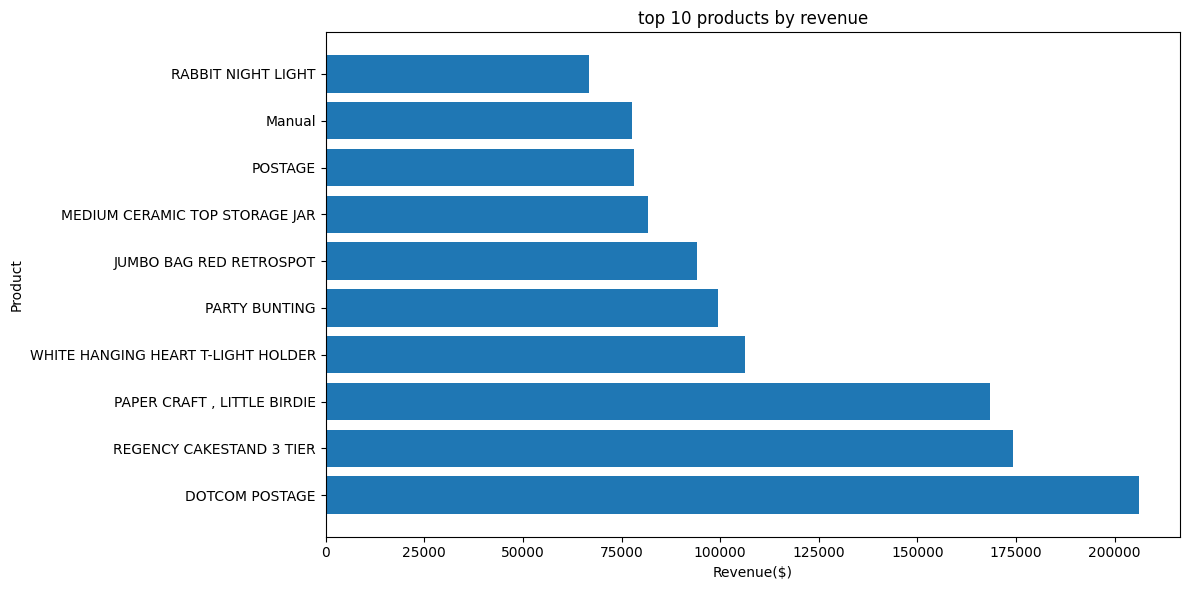

In [20]:
top10_products = product_revenue.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10_products.index, top10_products['totalRevenue'])

plt.title('top 10 products by revenue')
plt.xlabel('Revenue($)')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/top_10_products_revenue.png', dpi=300, bbox_inches='tight')

plt.show()

#top 10 countries by revenue

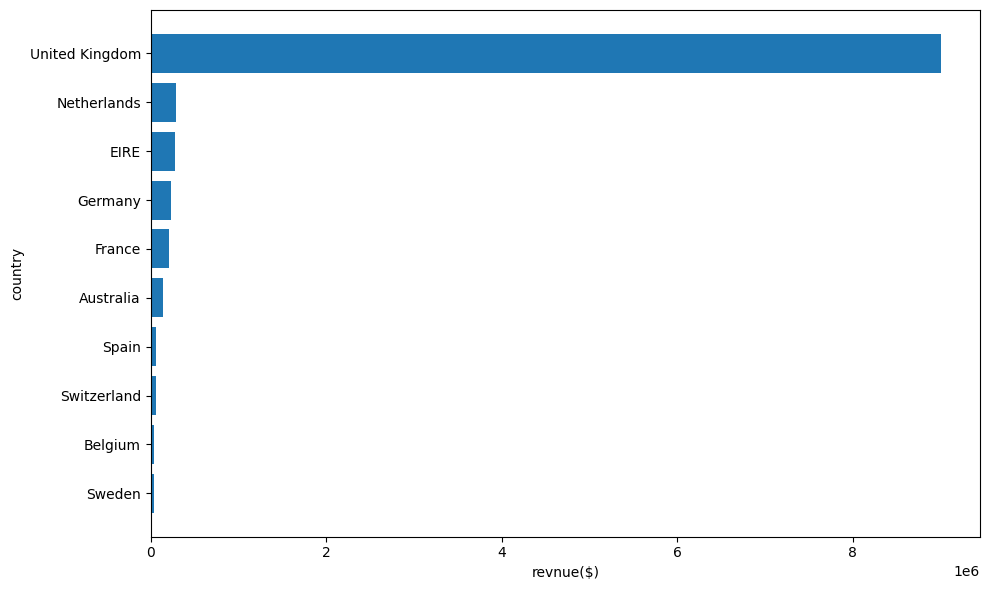

In [21]:
top10_countries = top_countries.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10_countries.index, top10_countries['totalRevenue'])
plt.xlabel('revnue($)')
plt.ylabel('country')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('images/top10_countries_revenue.png', dpi=300, bbox_inches='tight')

plt.show()

#order summary

In [25]:
order_summary = (df_clean.groupby('InvoiceNo')
                  .agg(OrderValue=('Revenue','sum'),
                       totalProducts=('Quantity','sum'),
                       UniqueItems=('StockCode', 'nunique')))

print('\n=============== order summary ===============\n')
print(order_summary.head())



=============== order summary ===============

           OrderValue  totalProducts  UniqueItems
InvoiceNo                                        
536365         139.12             40            7
536366          22.20             12            2
536367         278.73             83           12
536368          70.05             15            4
536369          17.85              3            1


#Order Value Distribution (Histogram)



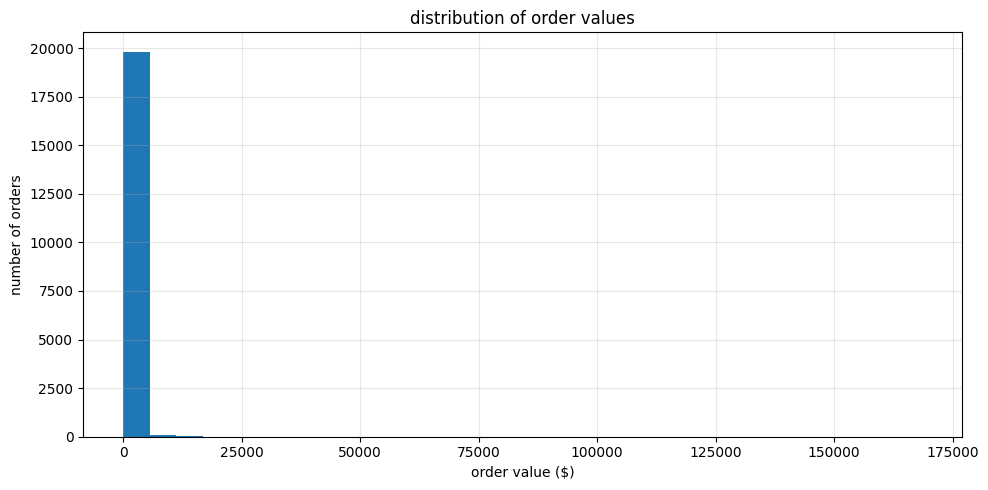

In [28]:
plt.figure(figsize=(10,5))

plt.hist(order_summary['OrderValue'], bins=30)
plt.title('distribution of order values')
plt.xlabel('order value ($)')
plt.ylabel('number of orders')
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('images/order_value_distribution.png', dpi=300, bbox_inches='tight')

plt.show()


#Order Value Box Plot

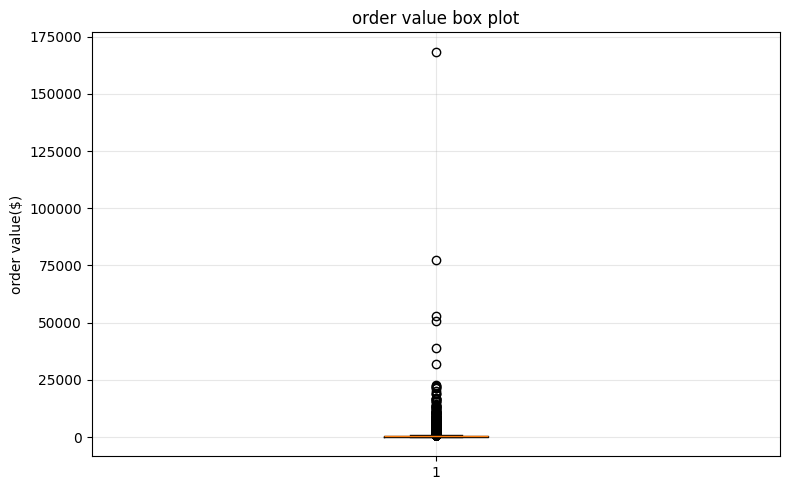

In [30]:
plt.figure(figsize=(8,5))

plt.boxplot(order_summary['OrderValue'])

plt.title('order value box plot')

plt.ylabel('order value($)')
plt.grid(alpha=.3)
plt.tight_layout()

plt.savefig('images/order_value_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()
